# <span style="color: red; font-weight:bold">  Multivariate Regime-Conditional Simulator 
## <span style="color: red; font-weight:bold"> Simulated World Project.
### <span style="color: brown; font-weight:bold"> Part 1.3: Synthetic Worlds. Factors, Return SImulation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KernelDensity
from hmmlearn.hmm import GaussianHMM
from scipy import stats 
from sklearn.linear_model import LinearRegression
from statsmodels.stats.diagnostic import acorr_ljungbox

## <span style="color: green; font-weight:bold"> Load data

#### <span style="color: brown; font-weight:bold"> Real world Data. 

In [2]:
# All features includes 'return', 'fwd_return', 'regime'
data_2 = pd.read_csv("project_DATA/_vet_features_df.csv", index_col="Date", parse_dates=True)
vet_features_df = data_2.copy(deep=True)
print("======== Full set of features. vet_features_df:")
vet_features_df

======== Full set of features. vet_features_df:


,Volume,VIX_indx_close,term_spread,T10Y3M,T10Y2Y_yield_curve,DGS10_dif,T10Y2Y_dif,DTB3_dif,news_sentiment,is_GDP_release_day,...,ADX_norm,return,fwd_return,log_ret,realized_vol,VIX_level,VIX_change,vol_z,hmm_regime,regime_name
Date,,,,,,,,,,,,,,,,,,,,,
2000-04-12,1175900000,28.980000,6.40,0.30,1,0.08,0.04,0.00,0.25,0,...,0.196604,-0.022271,-0.018171,-0.022523,0.011411,28.980000,0.061552,-0.688802,2,stress
2000-04-13,1032000000,29.400000,6.40,0.29,1,-0.03,-0.03,-0.02,0.23,0,...,0.203679,-0.018171,-0.058278,-0.018338,0.013253,29.400000,0.014389,0.458991,2,stress
2000-04-14,1279700000,33.490002,6.27,0.20,1,-0.09,0.04,0.00,0.22,0,...,0.226684,-0.058278,0.033084,-0.060045,0.013684,33.490002,0.130252,-0.247080,2,stress
2000-04-17,1204700000,28.950001,6.33,0.36,1,0.16,0.10,0.00,0.20,0,...,0.248046,0.033084,0.028663,0.032548,0.021878,28.950001,-0.145677,1.357060,2,stress
2000-04-18,1109400000,26.120001,6.33,0.40,1,0.04,0.04,0.00,0.20,0,...,0.253507,0.028663,-0.009808,0.028260,0.024516,26.120001,-0.102869,0.787515,2,stress
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,3820560000,14.000000,3.48,0.62,0,0.01,-0.03,0.00,-0.02,1,...,0.128592,0.004550,0.003221,0.004540,0.007379,14.000000,-0.005698,-0.490913,0,calm
2025-12-24,1798270000,13.470000,3.47,0.55,0,-0.03,-0.02,0.04,-0.00,0,...,0.134678,0.003221,-0.000304,0.003216,0.007096,13.470000,-0.038592,-0.994858,0,calm
2025-12-26,2586550000,13.600000,3.46,0.58,0,-0.01,0.00,-0.04,-0.01,0,...,0.141582,-0.000304,-0.003492,-0.000304,0.006772,13.600000,0.009605,-2.311361,0,calm


In [3]:
# Factors metrics sorted by pro_score_penalized. Correlated
data_3 = pd.read_csv("project_DATA/_pro_score_df_metrics_factors.csv")
factor_metrics_sorted = data_3.copy(deep=True)

In [4]:
# Factors-Metrics based on selected factors
factor_metrics = factor_metrics_sorted.T
headers = factor_metrics.iloc[0].values
factor_metrics.columns = headers
factor_metrics = factor_metrics.drop(index='factors')
print("======== factor_metrics:")
factor_metrics

======== factor_metrics:


,RSI_7_norm,RSI_14_norm,price_vs_EMA20,price_vs_EMA10,price_vs_SMA50,BB_position,high_close_ratio,price_vs_SMA20,VIX_indx_close,ROC_10,...,news_sentiment,Open_return,upper_wick,DGS10_dif,gap,T10Y3M,kin_f3_cpi_t10y3m,BB_width,DTB3_dif,gap_filled
pro_score,2.288127,1.87097,1.622433,1.411629,1.368139,1.362533,1.244761,1.104468,1.068365,1.035916,...,0.347958,0.198973,0.17336,0.116181,0.103163,0.16371,0.163114,0.071223,0.036235,0.018305
robust_score_3,2.037878,1.643392,1.435035,1.345246,1.138493,1.337038,1.289867,1.027222,0.889143,1.027313,...,0.434887,0.313312,0.266227,0.209125,0.187352,0.215877,0.213201,0.110298,0.075424,0.062604
ic_all,-0.056772,-0.048241,-0.044146,-0.05007,-0.03262,-0.047682,0.059749,-0.040647,0.02941,-0.041829,...,-0.026955,-0.034085,0.027268,-0.025488,-0.025472,-0.015419,0.015745,0.010117,-0.013073,0.030719
ic_calm,-0.08233,-0.079805,-0.066322,-0.064675,-0.058681,-0.07143,0.079496,-0.063137,0.068082,-0.049404,...,-0.030185,-0.028109,0.0339,-0.025626,-0.024635,-0.036986,0.037583,0.018623,0.002905,0.022897
ic_stress,-0.049543,-0.041717,-0.044277,-0.050893,-0.03663,-0.035603,0.085627,-0.036647,0.066273,-0.035603,...,-0.030884,-0.023033,0.02589,-0.050664,-0.040042,-0.022503,0.022323,0.019994,0.001216,0.042561
regime_gap,0.032787,0.038087,0.022045,0.013782,0.022052,0.035827,0.006132,0.026491,0.001809,0.013801,...,0.000699,0.005076,0.00801,0.025038,0.015407,0.014483,0.01526,0.001371,0.001689,0.019664
vol_sensitivity,0.034777,0.041967,0.032597,0.021256,0.036608,0.042795,0.007601,0.037935,0.037213,0.033933,...,0.002543,0.010821,0.001036,0.017824,0.022405,0.000328,0.000697,0.051525,0.004521,0.003222
stability_metric,1.391535,1.455437,1.378795,1.155797,1.563794,1.161985,0.949948,1.264372,1.502979,1.08059,...,0.642736,0.411835,0.431311,0.330091,0.319633,0.592094,0.603788,0.439669,0.232634,0.089175
bootstrap_IC_mean,-0.057212,-0.047761,-0.044276,-0.050432,-0.032899,-0.048197,0.060025,-0.040491,0.027781,-0.042236,...,-0.027975,-0.034312,0.027442,-0.025824,-0.025931,-0.015594,0.014842,0.010729,-0.013281,0.030789
bootstrap_IC_interval,0.039066,0.042299,0.042541,0.04333,0.045188,0.041887,0.044206,0.049839,0.046961,0.044427,...,0.041345,0.045102,0.044459,0.040761,0.04424,0.042771,0.042034,0.042767,0.040964,0.043857


In [5]:
factor_metrics.shape

(14, 24)

In [6]:
# Read selected_factors
print("======== Selected Factors:")
selected_factors_list = factor_metrics.columns.to_list()
selected_factors_list

======== Selected Factors:


['RSI_7_norm',
 'RSI_14_norm',
 'price_vs_EMA20',
 'price_vs_EMA10',
 'price_vs_SMA50',
 'BB_position',
 'high_close_ratio',
 'price_vs_SMA20',
 'VIX_indx_close',
 'ROC_10',
 'close_position',
 'body',
 'ROC_20',
 'Low_return',
 'news_sentiment',
 'Open_return',
 'upper_wick',
 'DGS10_dif',
 'gap',
 'T10Y3M',
 'kin_f3_cpi_t10y3m',
 'BB_width',
 'DTB3_dif',
 'gap_filled']

In [7]:
# the Markov transition matrix learned by GaussianHMM on real data
hmm_matrix = np.load('project_DATA/HMM_real_world_transition_matrix.npy')
trans_mat = hmm_matrix.copy()

print("======== HMM_trans_mat:")
print(trans_mat)
print(trans_mat.shape)

======== HMM_trans_mat:
[[9.79538250e-01 2.04617504e-02 1.06263579e-90]
 [1.80061367e-02 9.72568467e-01 9.42539597e-03]
 [1.87665236e-58 2.16112139e-02 9.78388786e-01]]
(3, 3)


In [8]:
# For research perpouse matrix. More aggresive stress regime
#trans_mat_research = [[0.97, 0.025, 0.005], [0.009, 0.97, 0.021], [0.001, 0.029, 0.97]]

#### <span style="color: brown; font-weight:bold">Real world HMM Regime Statistics

In [9]:
# HMM Regime Statistics
def hmm_regime_stat(df, col):
    sub_df = df[[col]].copy(deep=True)
    sub_df['run_id'] = (sub_df[col] != sub_df[col].shift()).cumsum()
    run_stats = sub_df.groupby([col, 'run_id']).size().reset_index(name='length')
    
    print("Section details:")
    print(run_stats)
    
    print("\nSummary:")
    summary = run_stats.groupby(col).agg(
        num_sections=('run_id', 'nunique'),
        total_count=('length', 'sum')
    )
    print(summary)

    return run_stats

In [10]:
# Real Stat
run_stat_real = hmm_regime_stat(vet_features_df, col='hmm_regime')

Section details:
     hmm_regime  run_id  length
0             0      13      37
1             0      15      17
2             0      17      48
3             0      19     164
4             0      21     116
..          ...     ...     ...
138           2     119       6
139           2     121      21
140           2     123      59
141           2     125      75
142           2     139      31

[143 rows x 3 columns]

Summary:
            num_sections  total_count
hmm_regime                           
0                     46         2431
1                     71         2773
2                     26         1264


In [11]:
# Calm(regime 0) vs Stress(regime 2) Distributions Vizualization
def calm_stress_regime_viz(stats_df, col):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot for regime 0
    stats_df[stats_df[col] == 0]['length'].hist(ax=axes[0], bins=30)
    axes[0].set_title('Distribution of Section Lengths for Regime 0(Calm)')
    axes[0].set_xlabel('Section Length')
    axes[0].set_ylabel('Frequency')
    
    # Plot for regime 1
    stats_df[stats_df[col] == 2]['length'].hist(ax=axes[1], bins=30)
    axes[1].set_title('Distribution of Section Lengths for Regime 2(Stress)')
    axes[1].set_xlabel('Section Length')
    
    # Plot for regime 2
    
    
    plt.tight_layout()
    plt.show()

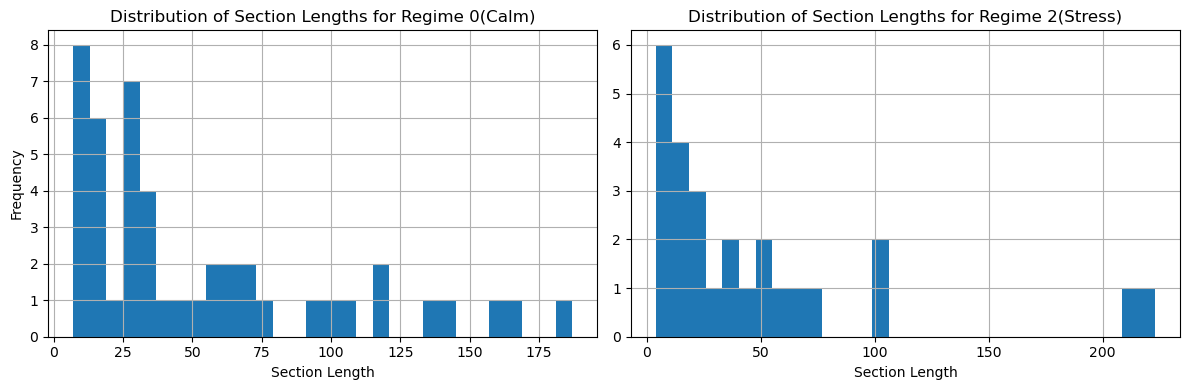

In [12]:
# Check the regimes destribution on Real world
calm_stress_regime_viz(run_stat_real, col='hmm_regime')

# <span style="color: red; font-weight:bold"> Simulate Regime

## <span style="color: green; font-weight:bold">Simulate the world, Copula path

In [13]:
# 1. Simulate regimes. Use the real world HMM probability matrix
def simulate_regimes(T, trans_mat, init_state=0):
    states = [init_state]

    for _ in range(T-1):
        current = states[-1]
        next_state = np.random.choice(
            len(trans_mat),
            p=trans_mat[current]
        )
        states.append(next_state)
        col = ['hmm_regime']

    return pd.DataFrame(data=np.array(states), columns=col)

In [14]:
# number of observations
T=len(vet_features_df)

#### Simulate regimes

In [22]:
simulate_regimes_df = simulate_regimes(T, trans_mat, init_state=0)
simulate_regimes_df['hmm_regime'].value_counts(dropna=False)

hmm_regime
0    2867
1    2233
2    1368
Name: count, dtype: int64

#### <span style="color: brown; font-weight:bold"> Simulated world HMM Regime Statistics

In [23]:
# Simulated Stat
run_stat_sim = hmm_regime_stat(simulate_regimes_df, col='hmm_regime')

Section details:
     hmm_regime  run_id  length
0             0       1       7
1             0       3      12
2             0      11       6
3             0      19      87
4             0      21      35
..          ...     ...     ...
164           2     133       7
165           2     147      86
166           2     155      12
167           2     159      19
168           2     163      51

[169 rows x 3 columns]

Summary:
            num_sections  total_count
hmm_regime                           
0                     56         2867
1                     84         2233
2                     29         1368


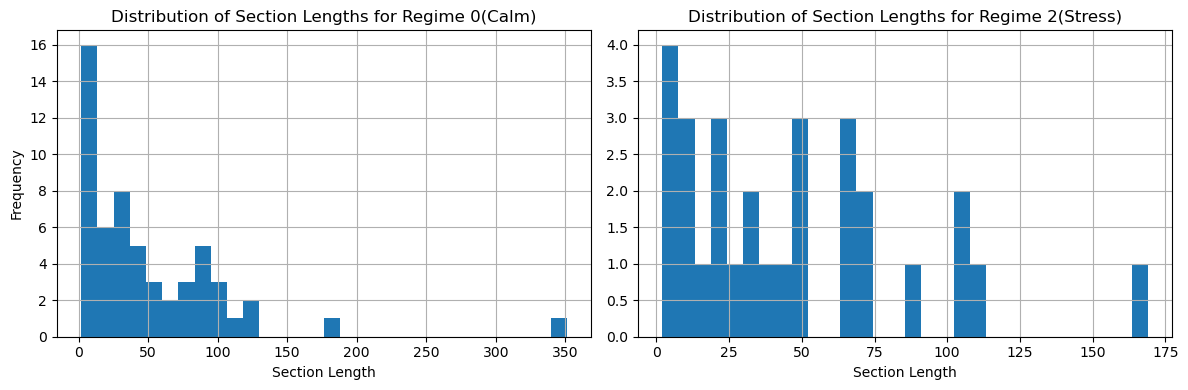

In [24]:
# Check the regimes destribution on Simulated world
calm_stress_regime_viz(run_stat_sim, col='hmm_regime')

#### <span style="color: brown; font-weight:bold"> Gaussian Copula Simulator
    '''
    Any joint distribution can be decomposed into two separate pieces — 
    the marginal distributions of each variable individually, 
    and a copula that describes the dependence structure between them.
    '''

#### <span style="color: brown; font-weight:bold"> Fit Multivariate per regime. Goal: to define the "parameters" of selected factors to simulate them 

In [25]:
count_regime_0 = (simulate_regimes_df['hmm_regime'] == 0).sum()
count_regime_1 = (simulate_regimes_df['hmm_regime'] == 1).sum()
count_regime_2 = (simulate_regimes_df['hmm_regime'] == 2).sum()
count_regime_0, count_regime_1, count_regime_2

(np.int64(2867), np.int64(2233), np.int64(1368))

In [26]:
# ================ Step 1 — Rank-Gaussian transform
def rank_gauss(x):
    r = stats.rankdata(x)/(len(x)+1)      # Convert to percentiles (0 to 1). Original => Uniform
    return stats.norm.ppf(r)              # # Map percentiles to Gaussian quantiles. Uniform => Gaussian

In [27]:
# ============== Step 2 — Fit copula per regime. 
# Learning the Dependence structure separately for each market regime.

def fit_copula(df_in, features, regime_col):

    df = df_in.copy(deep=True)
    
    models = {}

    for r in sorted(df[regime_col].unique()):
        sub = df[df[regime_col]==r][features].dropna()
        print(f"len of sub{r}['data']: {len(sub)}")
        # Transforms each column from original distribution to standard normal.
        Z = np.column_stack([
            rank_gauss(sub[c]) for c in features
        ])

        Sigma = np.cov(Z.T) # np.cov() expects variables in rows, observations in columns

        models[r] = {
            "cov": Sigma,
            "data": sub
        }

    return models

In [28]:
# Get Copula destribution models
models = fit_copula(vet_features_df, selected_factors_list, regime_col="hmm_regime")

len of sub0['data']: 2431
len of sub1['data']: 2773
len of sub2['data']: 1264


In [29]:
len(selected_factors_list)

24

In [30]:
# Factors sampling simulation function
def sample_copula(models, features, regime, n):
    '''
    Generating Synthetic Data
    '''
    m = models[regime]
    
    # Generates new samples with the same correlation structure
    Z = np.random.multivariate_normal(   
        np.zeros(len(features)),
        m["cov"],
        size=n
    )
    
    U = stats.norm.cdf(Z)
    X = np.zeros_like(U)  

    '''
    **Inverse ECDF** — uses the uniform values as quantile lookup indices into the original sorted real-world data.
    So if `U=0.9`, it picks the 90th percentile value from the actual observed distribution of that feature. 
    This is what makes it non-parametric.
    '''
    # inverse ECDF. Restores realistic non-normal distributions (fat tails, skewness)
    for j,c in enumerate(features):
        sorted_vals = np.sort(m["data"][c])
        idx = (U[:,j]*(len(sorted_vals)-1)).astype(int)

        # Takes data from real set but This works because of Sklar's Theorem:
        '''
        The Statistical Principle
        The dependency structure is separate from the marginal distributions
        We can "break" the original rows and "recombine" values
        As long as we preserve:
        The correlation structure (via Gaussian copula)
        The individual distributions (via lookup from sorted values) 
        '''
        X[:,j] = sorted_vals[idx]

    return pd.DataFrame(data=X, columns=features)

In [31]:
# Generate Factors Sample DF based on regime
copula_factors_sim_0 = sample_copula(models, selected_factors_list, regime=0, n=count_regime_0)
copula_factors_sim_1 = sample_copula(models, selected_factors_list, regime=1, n=count_regime_1)
copula_factors_sim_2 = sample_copula(models, selected_factors_list, regime=2, n=count_regime_2)
# Copy
simulated_F_R0 = copula_factors_sim_0.copy(deep=True)
simulated_F_R1 = copula_factors_sim_1.copy(deep=True)
simulated_F_R2 = copula_factors_sim_2.copy(deep=True)

simulated_F_R0.shape, simulated_F_R1.shape, simulated_F_R2.shape

((2867, 24), (2233, 24), (1368, 24))

#### <span style="color: brown; font-weight:bold"> Concut simuated_regime_df(regime column only) + simulated_F_R0, simulated_F_R1, simulated_F_R2 
    row by row based on regime mark 0,1,2

In [32]:
# Create a mapping array for each regime
regime_indices = {
    0: np.arange(len(simulated_F_R0)),
    1: np.arange(len(simulated_F_R1)),
    2: np.arange(len(simulated_F_R2))
}

# Create a counter for each regime
regime_positions = {0: 0, 1: 0, 2: 0}
regime_column = 'hmm_regime'

# Pre-allocate list for efficiency
rows_list = []

for regime in simulate_regimes_df[regime_column]:
    regime = int(regime)
    pos = regime_positions[regime]
    
    # Get the specific row
    if regime == 0:
        row = simulated_F_R0.iloc[[pos]]
    elif regime == 1:
        row = simulated_F_R1.iloc[[pos]]
    else:  # regime == 2
        row = simulated_F_R2.iloc[[pos]]
    
    rows_list.append(row)
    regime_positions[regime] += 1

# Combine
df_first_sim = pd.concat(rows_list, ignore_index=True)
df_first_sim['hmm_regime'] = simulate_regimes_df[regime_column].values

#### <span style="color: brown; font-weight:bold"> First Factor's Simulated Set

In [33]:
# First simulated set of selected factors + 'hmm_regime'
df_first_sim.shape

(6468, 25)

#### <span style="color: brown; font-weight:bold"> Final Set with Cliped Simulated Factor's 

In [34]:
# Clip sim_factors
def clip_to_empirical_by_regime(df_sim_sim, df_real_real, factors):
    """
    Clip simulated values to empirical quantiles based on regime.
    Parameters:
    df_sim: DataFrame with simulated data (will be modified)
    df_real: DataFrame with real data containing 'hmm_regime' column
    factors: list of column names to clip
    """
    df_sim = df_sim_sim.copy(deep=True)
    df_real = df_real_real.copy(deep=True)
    
    # Get unique regimes
    regimes = df_real['hmm_regime'].unique()

    for regime in regimes:
        # Select data for this regime
        mask = df_real['hmm_regime'] == regime
        regime_data = df_real.loc[mask]
        
        if len(regime_data) == 0:
            continue

     # Set quantiles based on regime
        if regime == 0:
            lo_q, hi_q = 0.01, 0.99
        elif regime == 2:
            lo_q, hi_q = 0.001, 0.999
        else:
            # Default quantiles for other regimes
            lo_q, hi_q = 0.01, 0.99
            
        # Clip each feature for this regime
        for col in factors:
            if col in regime_data.columns:
                lo = regime_data[col].quantile(lo_q)
                hi = regime_data[col].quantile(hi_q)
                
                # Apply clipping only to rows in this regime
                regime_mask_sim = df_sim['hmm_regime'] == regime
                df_sim.loc[regime_mask_sim, col] = df_sim.loc[regime_mask_sim, col].clip(lo, hi)
    
    return df_sim

In [35]:
# Simulate clipted_factors, no returns simulated
df_clipped_sim = clip_to_empirical_by_regime(df_first_sim, vet_features_df, selected_factors_list)

#### <span style="color: brown; font-weight:bold"> Check the factors destribution on real world vs simulated

In [36]:
# Random factors set to check destribution
factors_to_check = ['VIX_indx_close', 'high_close_ratio', 'DTB3_dif', 'Open_return', 'kin_f3_cpi_t10y3m', 'T10Y3M']

# Real world Selected factors destrib
print(f"==================")
print(f"||     Real     ||")
print(f"==================")

vet_features_df[factors_to_check].describe()

||     Real     ||


,VIX_indx_close,high_close_ratio,DTB3_dif,Open_return,kin_f3_cpi_t10y3m,T10Y3M
count,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000
mean,19.799405,1.006087,-0.000252,0.000300,-1.429431,1.439487
std,8.401821,0.007971,0.043878,0.011369,1.300672,1.296867
min,9.140000,1.000000,-0.810000,-0.087119,-4.271095,-1.730000
25%,13.960000,1.001192,-0.010000,-0.004421,-2.472500,0.350000
50%,17.690001,1.003283,0.000000,0.000756,-1.550000,1.560000
75%,23.132499,1.007976,0.010000,0.005730,-0.350000,2.480000
max,82.690002,1.104767,0.740000,0.106712,2.017783,3.870000


In [37]:
# First Simulated 
print(f"==================")
print(f"||  Simulated_1 ||")
print(f"==================")

df_first_sim[factors_to_check].describe()

||  Simulated_1 ||


,VIX_indx_close,high_close_ratio,DTB3_dif,Open_return,kin_f3_cpi_t10y3m,T10Y3M
count,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000
mean,19.461020,1.005834,-0.000057,0.000481,-1.399596,1.404283
std,8.524329,0.007495,0.044210,0.011455,1.277890,1.276002
min,9.150000,1.000000,-0.810000,-0.087119,-3.820000,-1.730000
25%,13.500000,1.001175,-0.010000,-0.003982,-2.432500,0.330000
50%,16.700001,1.003184,0.000000,0.000842,-1.520000,1.530000
75%,23.162500,1.007664,0.010000,0.005798,-0.330000,2.450000
max,80.860001,1.095567,0.610000,0.106513,1.730000,3.810000


In [38]:
# After bouds Standartization and cliped by regimes
print(f"==================")
print(f"|| Simulated_2  ||")
print(f"==================")

df_clipped_sim[factors_to_check].describe()

|| Simulated_2  ||


,VIX_indx_close,high_close_ratio,DTB3_dif,Open_return,kin_f3_cpi_t10y3m,T10Y3M
count,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000
mean,19.461241,1.005811,-0.000121,0.000472,-1.399692,1.404479
std,8.519191,0.007442,0.040859,0.011369,1.276073,1.274202
min,9.636000,1.000000,-0.548960,-0.083953,-3.820000,-1.472800
25%,13.530000,1.001175,-0.010000,-0.003982,-2.432500,0.330000
50%,16.700001,1.003184,0.000000,0.000842,-1.520000,1.530000
75%,23.162500,1.007664,0.010000,0.005798,-0.330000,2.450000
max,80.649600,1.094833,0.575810,0.099045,1.482800,3.720000


# <span style="color: red; font-weight:bold">simulate RETURNS

    Simulate Returns from factors (β-model) add temporal memory (AR structure)
    - regime-conditioned β model
    - regime AR(1)
    - regime volatility
    - fat tails

    Regime simulated srtuctural model:
    r(t) = mu(r) + b(r)T(F(t) - mu(F,r)) + phi(r) * r(t-1) + eps(t,r)
    eps(t,r) ~ t_v(0,sigma(r))

In [39]:
# AR() returns on Real world
'''
Calculates the AR(1) autocorrelation coefficient (phi) -
is the lag-1 autocorrelation coefficient
for returns within each HMM regime separately
'''
def regime_ar1(df_rw, regime):
    df = df_rw.copy(deep=True)

    # Selects only rows belonging to the target regime (0, 1, or 2).
    mask = df["hmm_regime"] == regime 

    r_t = df["return"]
    r_lag = r_t.shift(1) # return from previous period
    # Each row now has r_t (today) and r_lag (yesterday).
   
    # Key filter — both today AND yesterday must be in the same regime.
    # This avoids correlating a return from one regime with a return 
    # from a completely different regime context.
    valid = mask & mask.shift(1)

    return np.corrcoef(r_lag[valid], r_t[valid])[0,1]

In [40]:
# phi by regime
phi_0 = regime_ar1(vet_features_df, regime=0)   # calm
phi_1 = regime_ar1(vet_features_df, regime=1)   # transition
phi_2 = regime_ar1(vet_features_df, regime=2)   # stress


In [41]:
# Real world phi dict
phi_dict_real = {
    0: phi_0,   # calm
    1: phi_1,   # transition
    2: phi_2    # stress
}

In [42]:
phi_dict_real

{0: np.float64(-0.06953743497372676),
 1: np.float64(-0.03864943565307201),
 2: np.float64(-0.14768316509818616)}

In [43]:
# Estimate on REAL data
def calibrate_regime_model(df_rw, features,
                           return_col="fwd_return",
                           regime_col="hmm_regime"):
    '''
    This function calibrates a regime-switching model on Real Data. 
    It estimates separate parameters for each regime (state) in the data, 
    including regression coefficients, means, and volatility.

    Parameters:
    'df_rw': Input DataFrame containing the data
    'features': List of column names to use as predictor variables (factors)
    'return_col': Name of the target variable column (default: "fwd_return")
    'regime_col': Name of the column identifying which regime each row belongs to (default: "hmm_regime")

    Output:
    Returns a tuple of 4 dictionaries:
    "betas": Regression coefficients for each regime (slope factor)
    "factor_means": Mean values of features for each regime
    'return_means': Mean return for each regime
    'sigma_dict': Residual volatility for each regime
    '''

    df = df_rw.copy(deep=True)
    betas = {}            # Dictionary to store regression coefficients
    factor_means = {}
    return_means = {}
    #phi_dict = {}
    sigma_dict = {}

    for r in sorted(df[regime_col].unique()):

        sub = df[df[regime_col] == r].copy()

        # -------------------------
        # AR(1)
        # -------------------------
        #phi = sub[return_col].autocorr(lag=1)
        #phi_dict[r] = phi

        # -------------------------
        # Center X and y
        # -------------------------
        X = sub[features]
        y = sub[return_col]

        mu_F = X.mean().values   # numpy.ndarray
        mu_r = y.mean()          # scalar

        X_centered = X - mu_F
        y_centered = y - mu_r

        # -------------------------
        # Regression
        # -------------------------
        reg = LinearRegression()
        reg.fit(X_centered, y_centered)

        beta = reg.coef_
        '''
        'beta' is a NumPy array containing the regression coefficients (slopes)
        for each feature in the model. 
        Each coefficient tells you how much the target variable (return) changes
        when that specific feature changes by one unit, holding all other features constant.
        '''

        # -------------------------
        # Residual volatility
        # -------------------------
        residuals = y_centered - reg.predict(X_centered) # Prediction errors (epsilon)
        # Positive = model under-predicted
        # Negative = model over-predicted

        print(f"Regime {r}, Mean residuals: {np.mean(residuals)}")
        
        sigma_r = residuals.std()    # Standard deviation of residuals (of these errors)
        '''
        'sigma_r' is the standard deviation of the residuals - 
        the part of returns that model cannot explain using the features.
        It's a measure of the model's uncertainty or the "noise" in each regime.
        
        f.e.
        calm regime 0:
        sigma_r = 0.008 --> 0.8% volatility => Model is quite precise - errors are small and tight
        stress regime 2:
        sigma_r = 0.045 --> 4.5% volatility => Model is less precise - errors are larger and more spread out
        '''
        
        # -------------------------
        # Store
        # -------------------------
        betas[r] = beta
        factor_means[r] = mu_F
        return_means[r] = mu_r
        sigma_dict[r] = sigma_r

        print(f"Regime {r}: sigma_r = {sigma_dict[r]:.4f}")
        print(f"In Regime {r}:")
        print(f"  68% of prediction errors +/- {sigma_dict[r] * 100:.2f}%")
        print(f"  95% of prediction errors +/- {2 * sigma_dict[r] * 100:.2f}%")
        print(f"  Maximum typical error: +/-   {3 * sigma_dict[r] * 100:.2f}%")

    return betas, factor_means, return_means, sigma_dict

In [44]:
betas, factor_means, return_means, sigma_dict = calibrate_regime_model(
    vet_features_df, selected_factors_list,
    return_col="fwd_return", regime_col="hmm_regime"
)

Regime 0, Mean residuals: 1.1417349080883963e-20
Regime 0: sigma_r = 0.0059
In Regime 0:
  68% of prediction errors +/- 0.59%
  95% of prediction errors +/- 1.18%
  Maximum typical error: +/-   1.76%
Regime 1, Mean residuals: -4.003689234133273e-20
Regime 1: sigma_r = 0.0099
In Regime 1:
  68% of prediction errors +/- 0.99%
  95% of prediction errors +/- 1.98%
  Maximum typical error: +/-   2.97%
Regime 2, Mean residuals: 0.0
Regime 2: sigma_r = 0.0212
In Regime 2:
  68% of prediction errors +/- 2.12%
  95% of prediction errors +/- 4.24%
  Maximum typical error: +/-   6.36%


## <span style="color: blue; font-weight:bold"> Smulated Returns Regeme Engine

In [45]:
def simulate_returns_regime_engine(df_sim_sim,
                                   features,
                                   betas,
                                   factor_means,
                                   return_means,
                                   phi_dict,
                                   sigma_dict,
                                   regime_col="hmm_regime",
                                   df_t=8):
    
    df_sim = df_sim_sim.copy(deep=True)
    sim_r = np.zeros(len(df_sim))
   
    #---------------------------------#
    # initialise conditional variance #
    h = None
    omega = None
    prev_r = None
    
    # Starting values (GARCH-lite parameters):
    alpha = 0.02    # shock sensitivity
    beta_g = 0.90   # variance persistence
    #---------------------------------#
    
    for t in range(len(df_sim)):

        row = df_sim.iloc[t]
        r = int(row[regime_col])
        
        #---------------------------------#
        # When the regime changes (calm->stress), sigma_r jumps. 
        # We need to reset h at each regime transition to avoid a discontinuity:
        # Re-initialise h when regime changes
        if r != prev_r:
            h = sigma_dict[r]**2
            omega = sigma_dict[r]**2 * (1 - alpha - beta_g) # = sigma_r**2 × 0.08
            prev_r = r
        #---------------------------------#
        
        beta = betas[r]
        mu_F = factor_means[r]
        mu_r = return_means[r]
        phi = phi_dict[r]
        sigma_r = sigma_dict[r]

        F = row[features].values

        # centered signal
        signal = np.dot(beta, F - mu_F)

        # regime-specific fat-tailed noise. Scaled by today's conditional std
        #eps = np.random.standard_t(df=df_t) * sigma_r
        eps = np.random.standard_t(df=df_t) * np.sqrt(h)
        
        if t == 0:
            sim_r[t] = mu_r + signal + eps
        else:
            sim_r[t] = mu_r + signal + phi * sim_r[t-1] + eps
            
        #---------------------------------#
        # Update conditional variance (GARCH-lite)       
        # Return today = (volatility today) × (Student-t fat-tailed noise)
        # Volatility tomorrow = Long-term average + α × (Return today)^2 + β × (Volatility today)
        h = omega + alpha * eps**2 + beta_g * h
        #---------------------------------#

    df_sim["sim_return"] = sim_r
    return df_sim

In [46]:
# DF clipped_sim with 'return' simulated
df_clipped_sim_new = simulate_returns_regime_engine(
    df_clipped_sim, selected_factors_list, betas,
    factor_means, return_means, phi_dict_real,
    sigma_dict, regime_col="hmm_regime", df_t=8
)

In [47]:
#================================ VIZ CLOSE SIM vs REGIME SIM ========================================#

In [48]:
# Define your date ranges
def viz_sim_close_vs_regime_1500(combined_df):

    date_ranges = [
        (0, 1499),
        (1500, 2999),
        (3000, 4499),
        (4500, 5999),
        (6000, 6499)
    ]
    
    start_date = 0
    end_date = 6468
    
    # Create subplots
    n_plots = len(date_ranges)
    fig, axes = plt.subplots(n_plots, 1, figsize=(15, 5*n_plots))
    
    colors = {0: 'blue', 1: 'green', 2: 'red'}
    
    for idx, (start_date, end_date) in enumerate(date_ranges):
        # Filter data for this date range
        mask = (combined_df.index >= start_date) & (combined_df.index <= end_date)
        df_range = combined_df[mask]
        
        if len(df_range) > 0:
            ax = axes[idx]
            
            # Plot each regime
            for regime in df_range['hmm_regime'].unique():
                regime_mask = df_range['hmm_regime'] == regime
                
                if regime == 0:
                    regime_name = "calm"
                elif regime == 1:
                    regime_name = "transition"
                else:
                    regime_name = "stress"            
                    
                ax.scatter(df_range.index[regime_mask], 
                          df_range['sim_close'][regime_mask], 
                          c=colors.get(regime, 'gray'), 
                          label=f'Regime {regime_name}', 
                          s=10, alpha=0.7)
            
            ax.set_title(f'Simulated Period: {start_date} to {end_date}', fontsize=12)
            ax.set_ylabel('Simulated Close Price', fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
            ax.legend()   
    
    plt.tight_layout()
    plt.show()

In [49]:
# Generate realistic price data
regimes_sim = df_clipped_sim_new["hmm_regime"].copy(deep=True)
returns_sim = df_clipped_sim_new["sim_return"].copy(deep=True)

In [50]:
# Generate realistic price data
start_price = 1000
close_sim = start_price * np.exp(np.cumsum(returns_sim))
# Convert to data frame
regimes_sim_df = pd.DataFrame(regimes_sim)
close_sim_df = pd.DataFrame(close_sim)

In [51]:
# Align the data (make sure dates match)
combined_sim_df = pd.concat([close_sim_df, regimes_sim_df], axis=1).dropna()
combined_sim_df.rename(columns={'sim_return': 'sim_close'}, inplace=True)

In [52]:
combined_sim_df['sim_close'].min(), combined_sim_df['sim_close'].max()

(np.float64(505.47705192041093), np.float64(4196.8715756107895))

In [53]:
def all_data_viz(combined_df):
    # Create the plot
    plt.figure(figsize=(15, 8))
    
    # Scatter plot with colors based on regime
    colors = {0: 'blue', 1: 'green', 2: 'red'}  
    for regime in combined_df['hmm_regime'].unique():
        mask = combined_df['hmm_regime'] == regime

        if regime == 0:
            regime_name = "calm"
        elif regime == 1:
            regime_name = "transition"
        else:
            regime_name = "stress"    

       
        plt.scatter(combined_df.index[mask], 
                    combined_df['sim_close'][mask], 
                    c=colors.get(regime, 'gray'), 
                    label=f'Regime {regime_name}', 
                    s=10, alpha=0.7)
    
    plt.title('Simulated Close Price with HMM Regimes', fontsize=16)
    plt.xlabel('Days axis', fontsize=12)
    plt.ylabel('Close Price', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

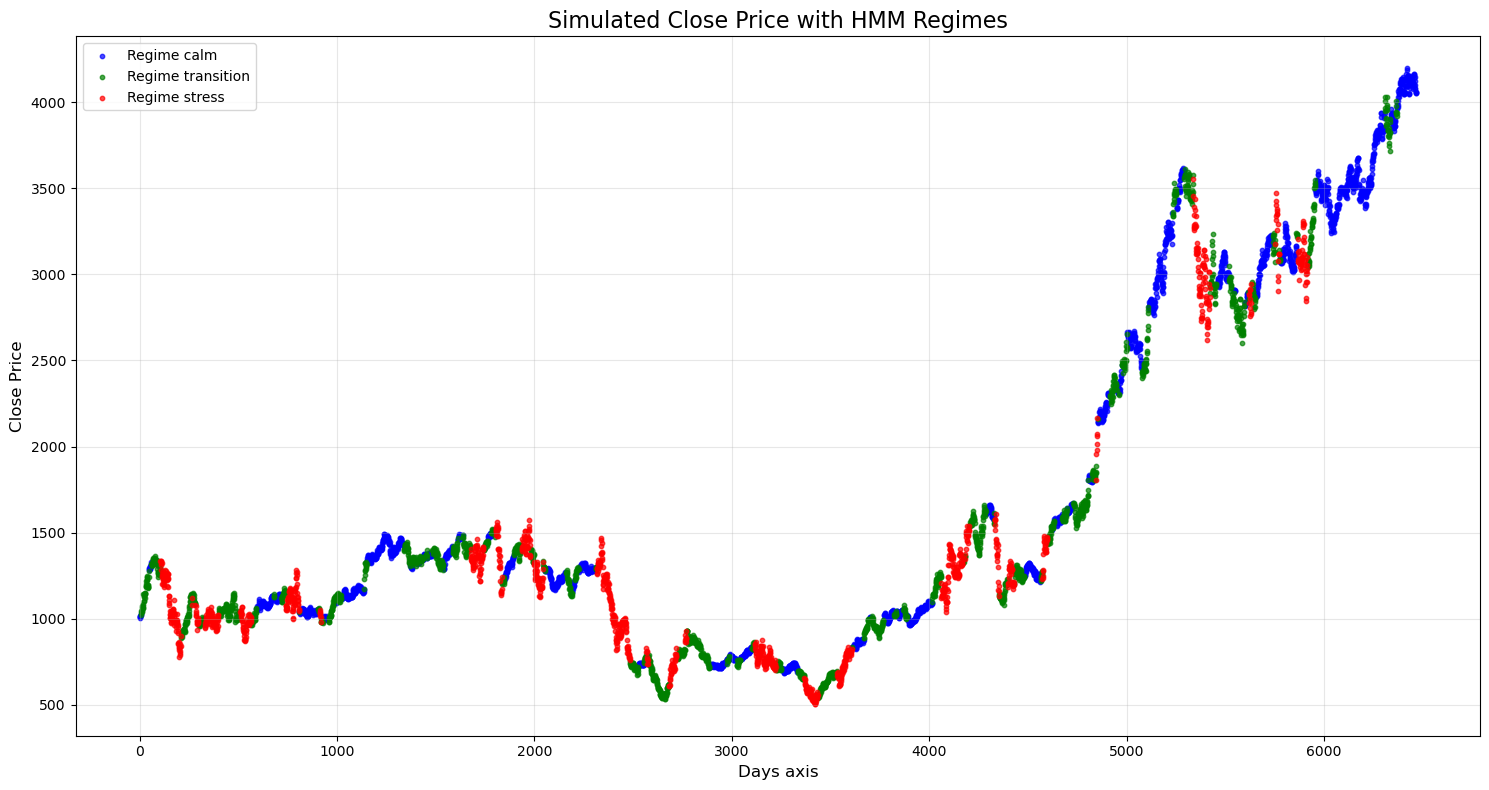

In [54]:
all_data_viz(combined_sim_df)

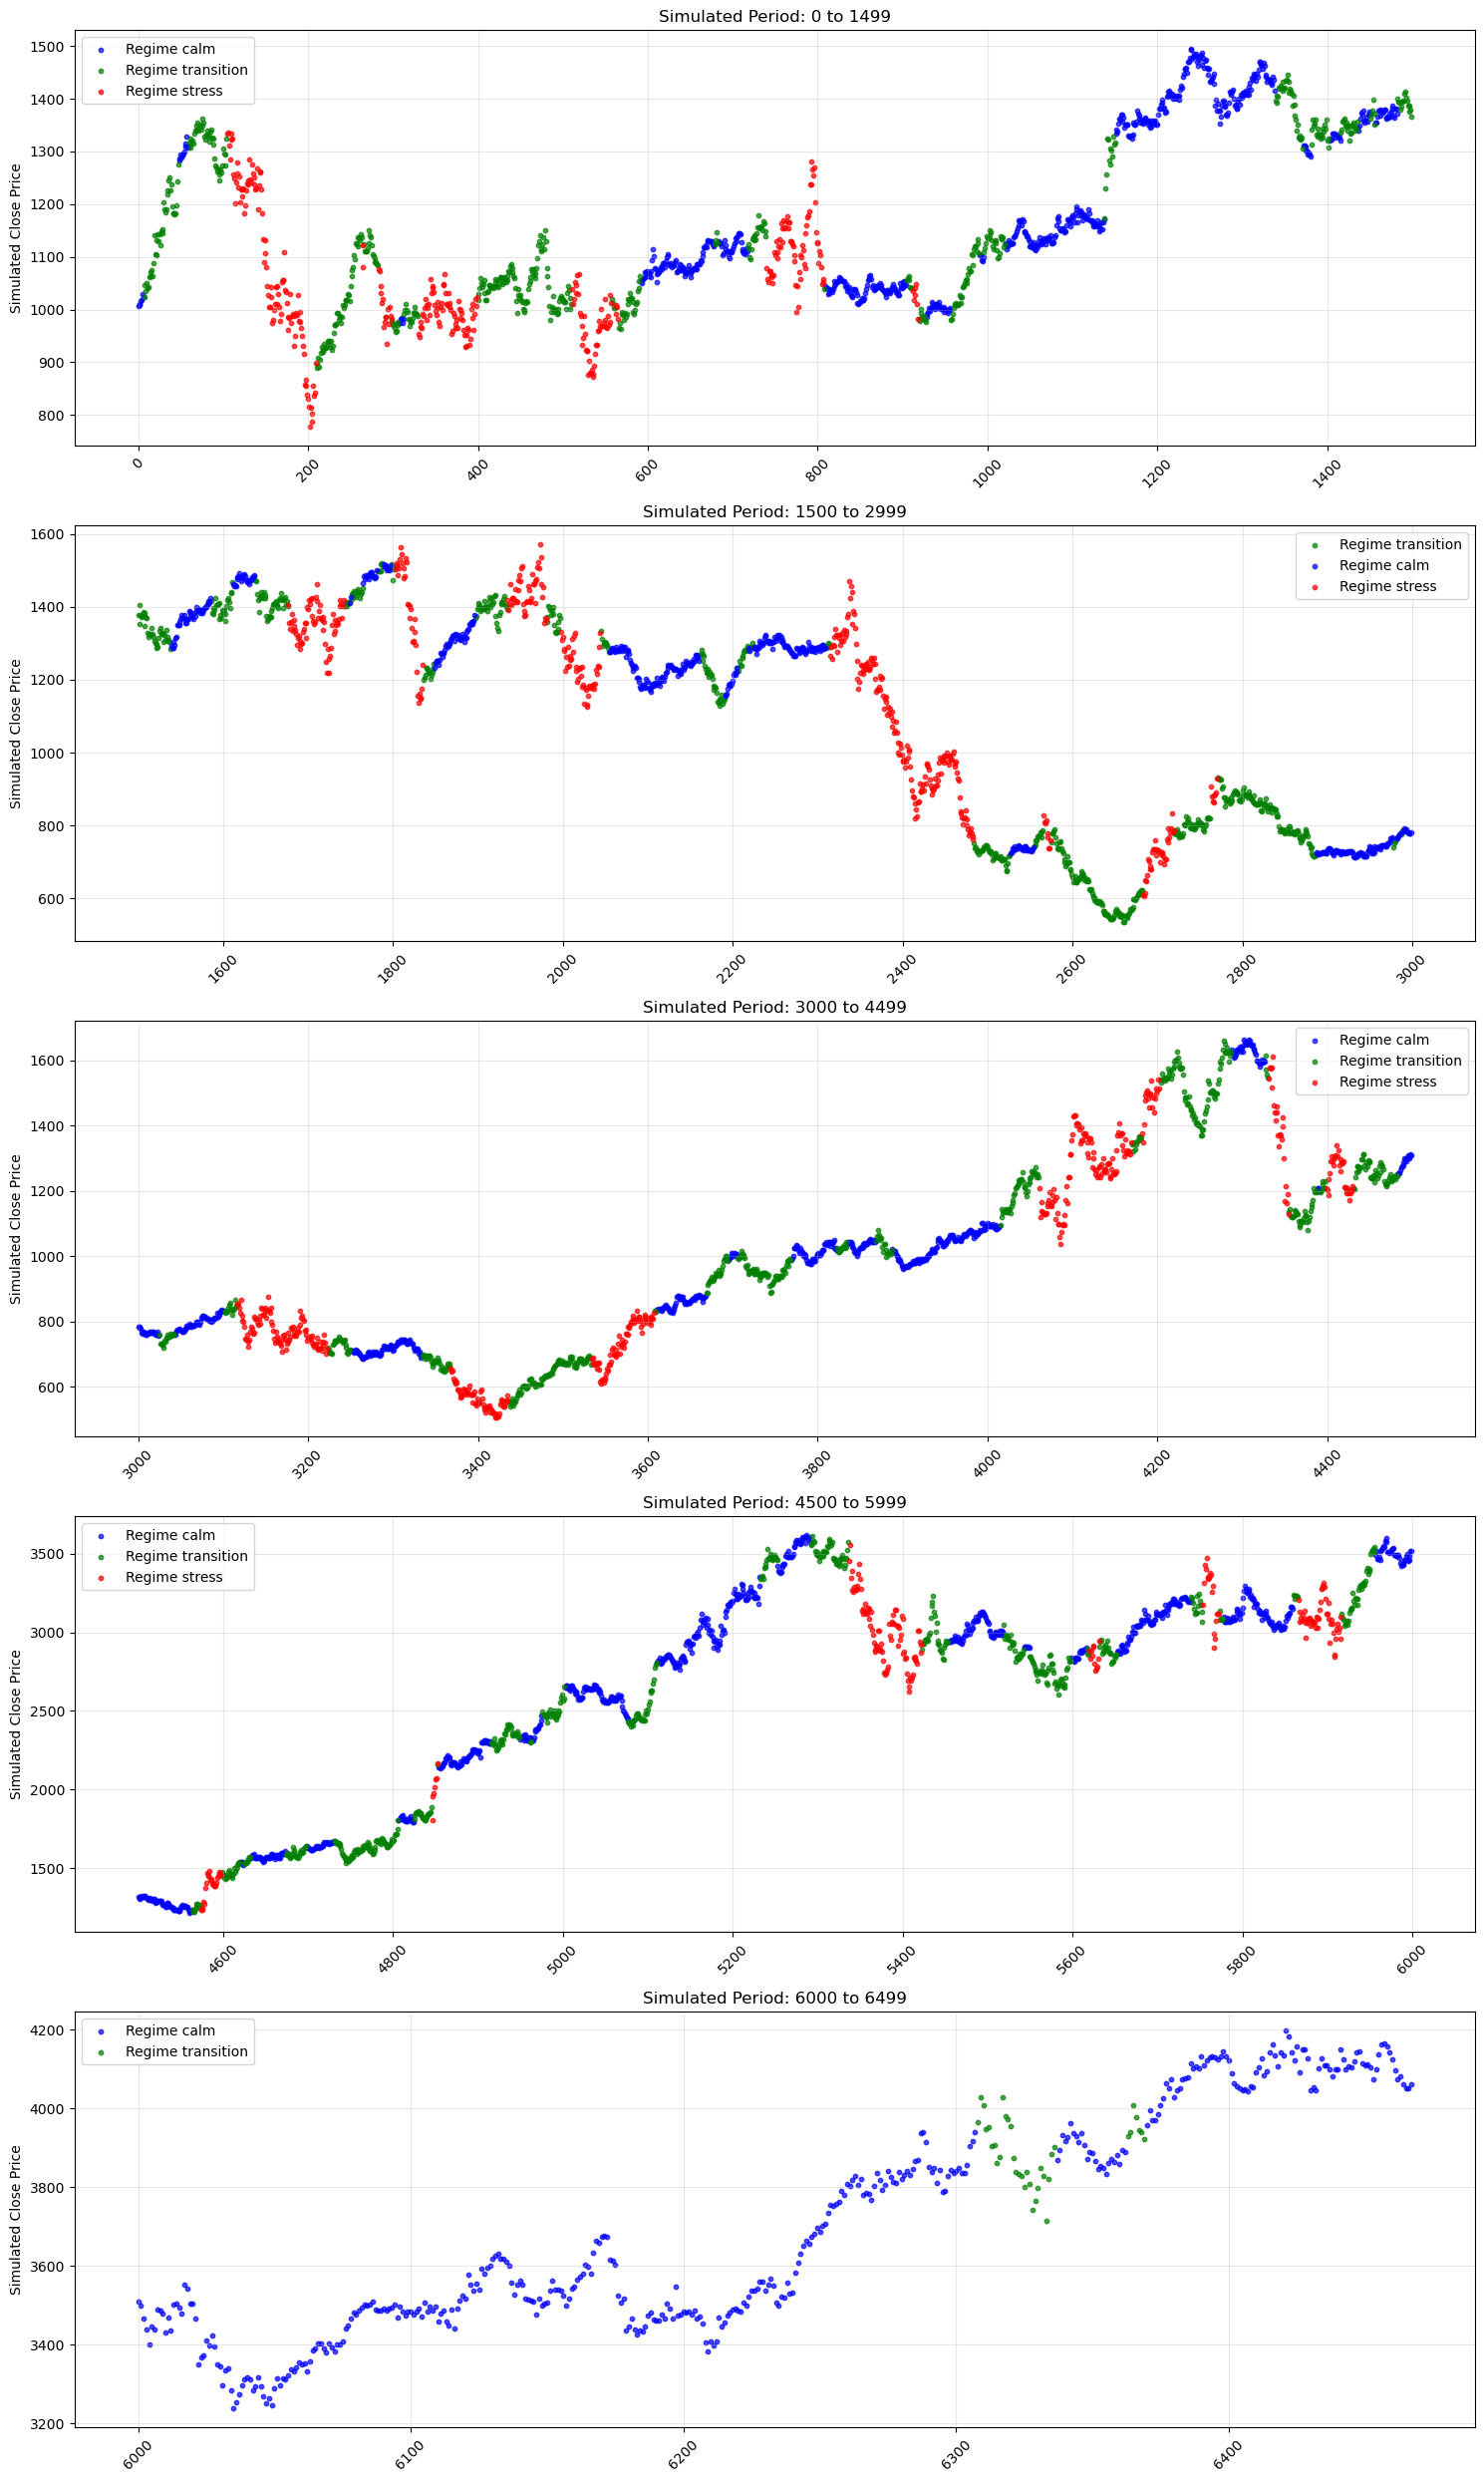

In [55]:
# Sliced dayes
viz_sim_close_vs_regime_1500(combined_sim_df)

### <span style="color: brown; font-weight:bold">Level Checks Sim vs Real

#### <span style="color: blue; font-weight:bold"> Destribution

In [56]:
# Real data 'high_close_ratio' 
vet_features_df[selected_factors_list + ["hmm_regime"] + ['fwd_return']]["high_close_ratio"].describe()

count    6468.000000
mean        1.006087
std         0.007971
min         1.000000
25%         1.001192
50%         1.003283
75%         1.007976
max         1.104767
Name: high_close_ratio, dtype: float64

In [57]:
# df_t=8 GARCH. Simulated data. Clipped. 'high_close_ratio' 
df_clipped_sim_new["high_close_ratio"].describe()

count    6468.000000
mean        1.005811
std         0.007442
min         1.000000
25%         1.001175
50%         1.003184
75%         1.007664
max         1.094833
Name: high_close_ratio, dtype: float64

In [58]:
# Real data 'fwd_return' 
vet_features_df[selected_factors_list + ["hmm_regime"] + ['fwd_return']]["fwd_return"].describe()

count    6468.000000
mean        0.000312
std         0.012166
min        -0.119841
25%        -0.004704
50%         0.000645
75%         0.005860
max         0.115800
Name: fwd_return, dtype: float64

In [59]:
# df_t=8 GARCH. Simulated data. Clipped. 'fwd_return' Destribution 0.02
df_clipped_sim_new["sim_return"].describe()

count    6468.000000
mean        0.000217
std         0.014901
min        -0.126992
25%        -0.005982
50%         0.000504
75%         0.006964
max         0.101665
Name: sim_return, dtype: float64

#### <span style="color: blue; font-weight:bold"> Autocorrelation

In [60]:
# Real data
vet_features_df['fwd_return'].autocorr(1)

np.float64(-0.10397140272057682)

In [61]:
# df_t=8 GARCH. Simulated clipped  a=0.02 b=0.90
df_clipped_sim_new['sim_return'].autocorr(1)

np.float64(-0.10722737759210585)

#### <span style="color: blue; font-weight:bold"> Regime-wise volatility match

In [62]:
# Real Regime Vol
vet_features_df.groupby('hmm_regime')['fwd_return'].std()

hmm_regime
0    0.005932
1    0.009972
2    0.021721
Name: fwd_return, dtype: float64

In [63]:
# df_t=8 GARCH. Simulated Regime vol. Clipped   a=0.02 b=0.90
df_clipped_sim_new.groupby('hmm_regime')['sim_return'].std()

hmm_regime
0    0.007028
1    0.012157
2    0.026531
Name: sim_return, dtype: float64

>Regime Volatility — Correct Shape, Slightly Over-Scaled

### <span style="color: blue; font-weight:bold"> Tail quantile comparison
#### <span style="color: blue; font-weight:bold"> Tail Behavior

In [64]:
# Real World
vet_features_df['fwd_return'].quantile([0.01, 0.99])

0.01   -0.03419
0.99    0.03353
Name: fwd_return, dtype: float64

In [65]:
# df_t=8 GARCH. Simulated clipped  a=0.02 b=0.90
df_clipped_sim_new['sim_return'].quantile([0.01, 0.99])

0.01   -0.046061
0.99    0.043582
Name: sim_return, dtype: float64

>Slightly Too Fat (too aggressive in heavy tails)

#### <span style="color: blue; font-weight:bold"> Factor Distribution

In [66]:
# Real world
vet_features_df['VIX_indx_close'].quantile([0.01, 0.99])

0.01    10.020000
0.99    53.016201
Name: VIX_indx_close, dtype: float64

In [67]:
# df_t=8 GR Simulated clipped
df_clipped_sim_new['VIX_indx_close'].quantile([0.01, 0.99])

0.01     9.9000
0.99    51.3465
Name: VIX_indx_close, dtype: float64

#### That is extremely close. This confirms:

>Copula marginals are correct

>Clipping barely activates

>No distortion after simulation

#### <span style="color: blue; font-weight:bold"> Correlation check
    If that is near zero -> good (independent world).
    If it’s high -> you accidentally leaked information.


In [68]:
# df_t=8 GARCH a=0.02 b=0.90
sim_return = df_clipped_sim_new['sim_return']
real_return = vet_features_df['fwd_return']

correlation_value = sim_return.corr(real_return.reset_index(drop=True))
print(f"The correlation between df_clipped_sim_new['sim_return'] and vet_features_df['fwd_return'] is: {correlation_value}")

# Calculate the correlation matrix
correlation_matrix = np.corrcoef(sim_return.abs(), real_return.abs())
print(f"The correlation_matrix is:\n {correlation_matrix}")

The correlation between df_clipped_sim_new['sim_return'] and vet_features_df['fwd_return'] is: 0.003838013469226042
The correlation_matrix is:
 [[ 1.         -0.02628604]
 [-0.02628604  1.        ]]


#### The correlation is near zero -> good, we have independent world
    ~0 means: simulator generates structurally similar but independent universes.

#### <span style="color: blue; font-weight:bold"> Perform the Ljung–Box test
    Purpose:
    Test whether the time series has significant autocorrelation up to a given lag.

In [69]:
# Real World
acorr_ljungbox(vet_features_df['fwd_return'], lags=[5,10,20])

,lb_stat,lb_pvalue
5,78.754034,1.529125e-15
10,107.486566,1.712345e-18
20,171.892935,3.712023e-26


In [70]:
"""
Very small p-values ->
Strong rejection of “no autocorrelation”.
real returns have a significant sequential structure.
"""

'\nVery small p-values ->\nStrong rejection of “no autocorrelation”.\nreal returns have a significant sequential structure.\n'

In [71]:
# df_t=8 GARCH. Simulated clipped a=0.02 b=0.90
acorr_ljungbox(df_clipped_sim_new['sim_return'], lags=[5,10,20])

,lb_stat,lb_pvalue
5,78.586101,1.657882e-15
10,84.485884,6.591865e-14
20,102.168706,5.143481e-13


In [ ]:
"""
Simulated returns behave like the real series across multiple lags.
Also extremely small -> Also strong serial dependence.
Simulator captures:
    - Short memory well
    - Medium memory partially
    - Long memory less strongly
"""

## <span style="color: red; font-weight:bold">Generate Simulated World

In [72]:
#=============================================================================
def generate_world(seed,
                   vet_features_df,
                   selected_factors_list,
                   betas,
                   factor_means,
                   return_means,
                   phi_dict,
                   sigma_dict,
                   trans_mat,
                   models=models,
                   df_t=8,
                   alpha=0.02,
                   beta_g=0.90):
    """
    Generate one complete synthetic world.
    All structure is fixed — only the random seed changes.
    """
    np.random.seed(seed)
    
    T = len(vet_features_df)
    
    # 1. Simulate regime path
    sim_regimes = simulate_regimes(T, trans_mat, init_state=0)
    
    # 2. Count regimes for copula sampling
    count_0 = (sim_regimes['hmm_regime'] == 0).sum()
    count_1 = (sim_regimes['hmm_regime'] == 1).sum()
    count_2 = (sim_regimes['hmm_regime'] == 2).sum()
    
    # 3. Fit copula models (on real data — fixed)
   # models = fit_copula(vet_features_df, selected_factors_list) - out of the loop now
    
    # 4. Sample factors per regime
    sim_F0 = sample_copula(models, selected_factors_list, regime=0, n=count_0)
    sim_F1 = sample_copula(models, selected_factors_list, regime=1, n=count_1)
    sim_F2 = sample_copula(models, selected_factors_list, regime=2, n=count_2)
    
    # 5. Assemble factor DataFrame in regime order
    regime_positions = {0: 0, 1: 0, 2: 0}
    rows_list = []
    for regime in sim_regimes['hmm_regime']:
        regime = int(regime)
        pos = regime_positions[regime]
        if regime == 0:   row = sim_F0.iloc[[pos]]
        elif regime == 1: row = sim_F1.iloc[[pos]]
        else:             row = sim_F2.iloc[[pos]]
        rows_list.append(row)
        regime_positions[regime] += 1
    
    df_world = pd.concat(rows_list, ignore_index=True)
    df_world['hmm_regime'] = sim_regimes['hmm_regime'].values
    
    # 6. Clip to empirical bounds
    df_world = clip_to_empirical_by_regime(
        df_world, vet_features_df, selected_factors_list
    )
    
    # 7. Simulate returns
    df_world = simulate_returns_regime_engine(
        df_world, selected_factors_list,
        betas, factor_means, return_means,
        phi_dict, sigma_dict,
        regime_col='hmm_regime',
        df_t=df_t
    )
    
    # 8. Tag world identity
    df_world['world_id'] = seed
    
    return df_world
#=============================================================================

## <span style="color: red; font-weight:bold">Generate N Simulated Worlds

In [74]:
# ============= Generate library ==============
N_WORLDS = 50

world_library = []
# Fit once — outside the loop
models = fit_copula(vet_features_df, selected_factors_list, regime_col="hmm_regime")
for seed in range(N_WORLDS):
    world = generate_world(seed, vet_features_df, selected_factors_list,
                           betas, factor_means, return_means,
                           phi_dict_real, sigma_dict, trans_mat, models)
    world_library.append(world)

# Stack all worlds into one DataFrame if needed
all_worlds_df = pd.concat(world_library, ignore_index=True)
print(f"Library: {N_WORLDS} worlds × {len(vet_features_df)} days = {len(all_worlds_df):,} rows")

len of sub0['data']: 2431
len of sub1['data']: 2773
len of sub2['data']: 1264
Library: 50 worlds × 6468 days = 323,400 rows


#### <span style="color: blue; font-weight:bold"> Destribution

In [75]:
# Real World
vet_features_df['fwd_return'].describe()

count    6468.000000
mean        0.000312
std         0.012166
min        -0.119841
25%        -0.004704
50%         0.000645
75%         0.005860
max         0.115800
Name: fwd_return, dtype: float64

In [76]:
# Simulated N Worlds
all_worlds_df['sim_return'].describe()

count    323400.000000
mean          0.000286
std           0.014360
min          -0.270685
25%          -0.006237
50%           0.000328
75%           0.006841
max           0.193836
Name: sim_return, dtype: float64

In [77]:
# Real World
vet_features_df.groupby('hmm_regime')['fwd_return'].std()

hmm_regime
0    0.005932
1    0.009972
2    0.021721
Name: fwd_return, dtype: float64

In [78]:
# df_t=8 GARCH. Simulated Regime vol. Clipped   a=0.02 b=0.90
all_worlds_df.groupby('hmm_regime')['sim_return'].std()

hmm_regime
0    0.007074
1    0.011872
2    0.026063
Name: sim_return, dtype: float64

In [79]:
# Real World
vet_features_df['fwd_return'].quantile([0.01, 0.99])

0.01   -0.03419
0.99    0.03353
Name: fwd_return, dtype: float64

In [80]:
# df_t=8 GARCH. Simulated a=0.02 b=0.90
all_worlds_df['sim_return'].quantile([0.01, 0.99])

0.01   -0.041726
0.99    0.042617
Name: sim_return, dtype: float64

In [81]:
# Generate realistic price data
def close_and_regime(returns_sim, regimes_sim, start_price=1000):
    
    close_sim = start_price * np.exp(np.cumsum(returns_sim))
    # Convert to data frame
    regimes_sim_df = pd.DataFrame(regimes_sim)
    close_sim_df = pd.DataFrame(close_sim)
    
    # Align the data (make sure dates match)
    combined_sim_df = pd.concat([close_sim_df, regimes_sim_df], axis=1).dropna()
    combined_sim_df.rename(columns={'sim_return': 'sim_close'}, inplace=True)

    return combined_sim_df

In [82]:
n_combined_sim_df = close_and_regime(all_worlds_df['sim_return'], all_worlds_df['hmm_regime'], start_price=1000)

In [84]:
n_combined_sim_df['hmm_regime'].value_counts()

hmm_regime
1    138358
0    124782
2     60260
Name: count, dtype: int64

================ Sliced vizualisation. Days 6 500 - 15 000 



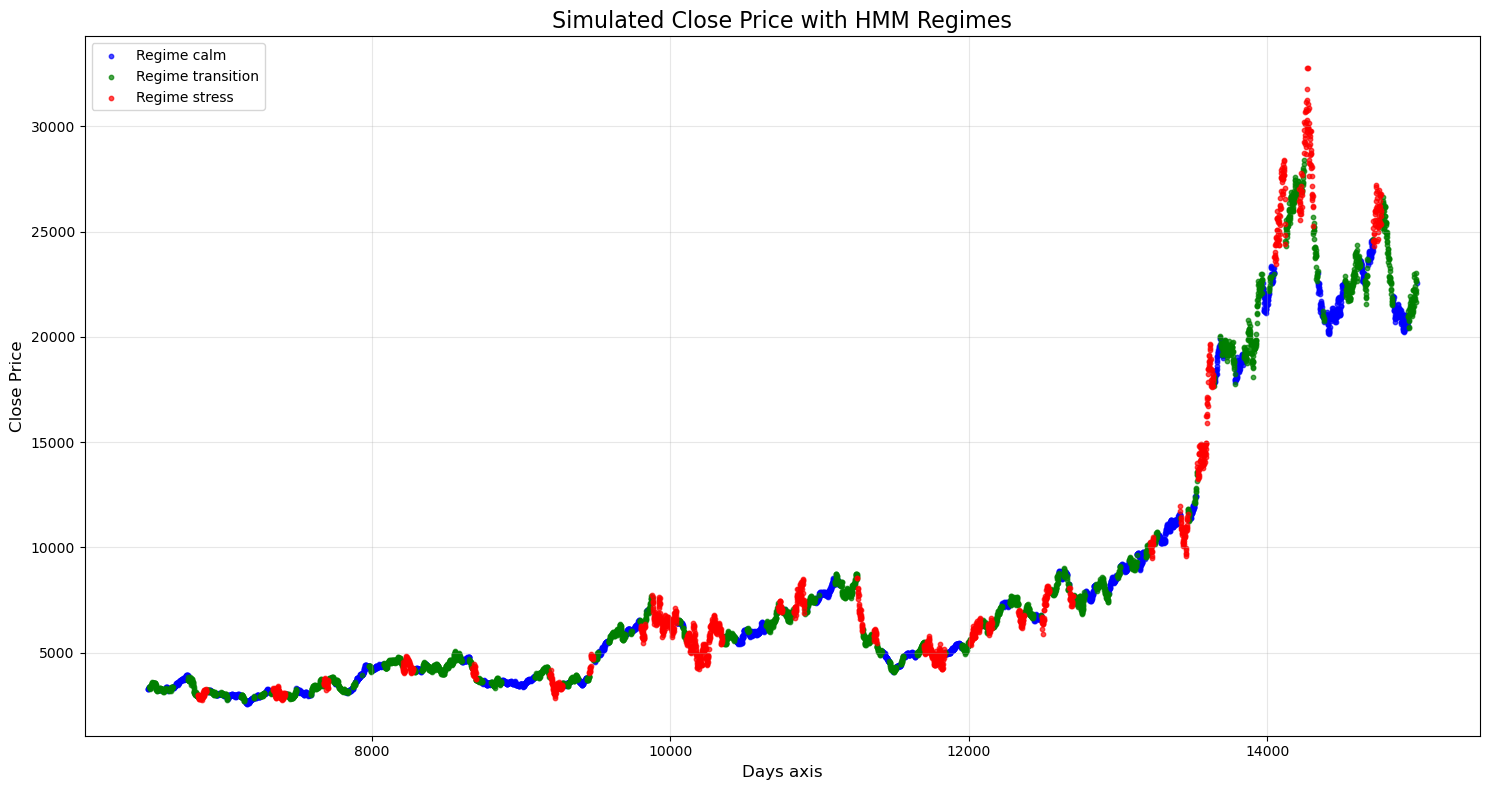


 ================ Inside sliced period vizualisation. Days 11500 - 13000 



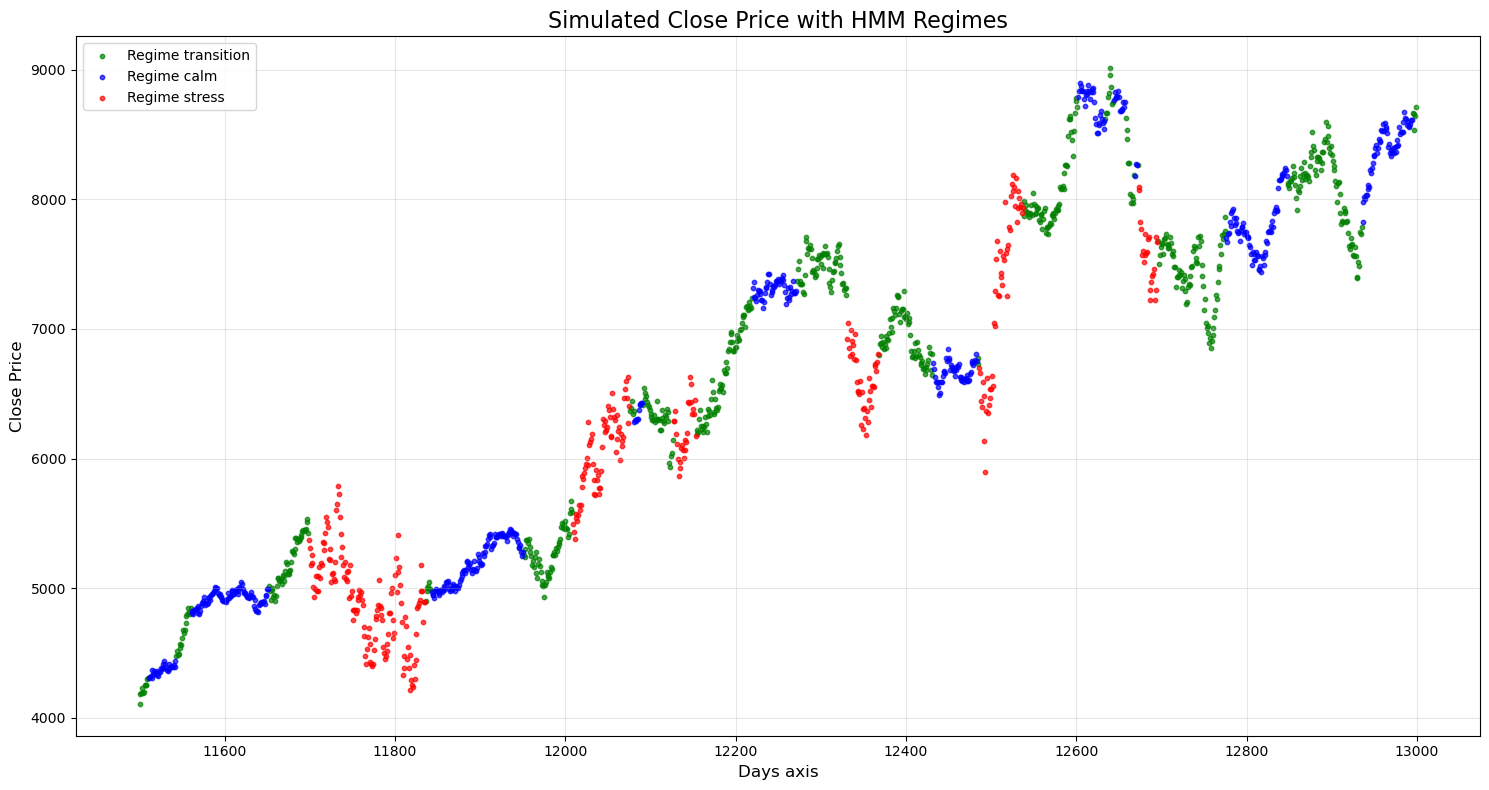

In [87]:
# Sliced vizualisation
print(f'================ Sliced vizualisation. Days 6 500 - 15 000 \n')
all_data_viz(n_combined_sim_df.iloc[6500: 15000])

# Inside sliced period
print(f'\n ================ Inside sliced period vizualisation. Days 11500 - 13000 \n')
all_data_viz(n_combined_sim_df.iloc[11500:13000])
